<a href="https://colab.research.google.com/github/Justin1230123/COIT20252-e-portfolio/blob/main/Assignment_one_Evolutionary_computation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training shape after augmentation: torch.Size([7413, 1, 804])
Epoch  30 | Train Loss: 0.5062 | Val Loss: 0.7143
Epoch  60 | Train Loss: 0.3581 | Val Loss: 0.6847
Epoch  90 | Train Loss: 0.3199 | Val Loss: 0.6588
Epoch 120 | Train Loss: 0.2941 | Val Loss: 0.6845
Epoch 150 | Train Loss: 0.2762 | Val Loss: 0.6804
Early stopping triggered at epoch 152
Loaded best model for final evaluation.


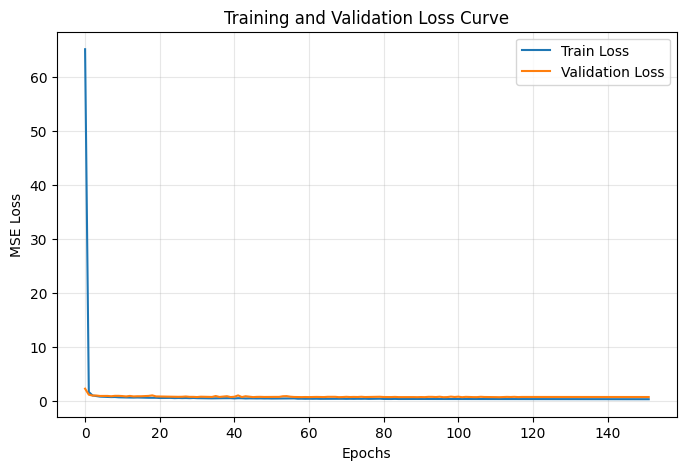


=== FINAL TEST RESULTS ===
Test MSE Loss : 0.9446
Test RMSE     : 0.972
Test R²       : 0.852


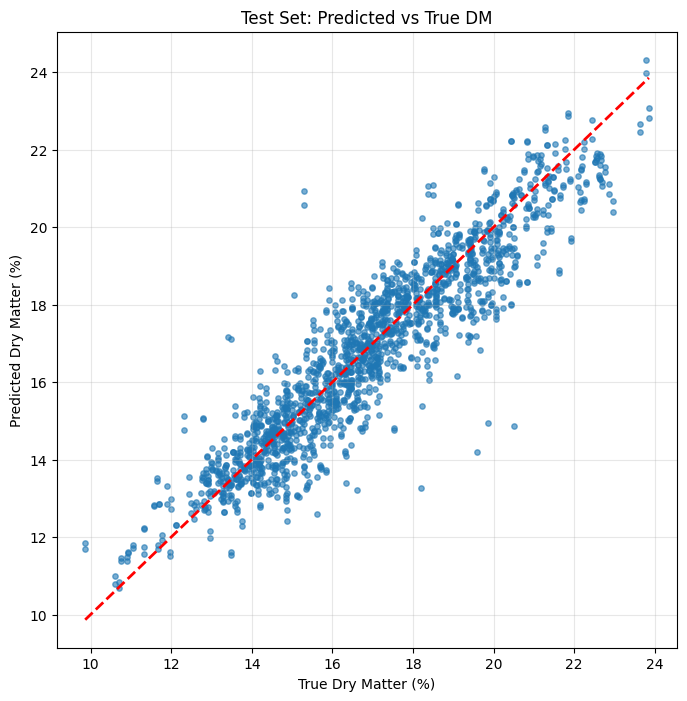

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, mean_squared_error
from google.colab import drive
import scipy.signal as signal

drive.mount('/content/drive')

# Step 1: Load NIR CSV data
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/mango_nir.csv")

# Step 2: Split data by type
train_df = df[df['Data Type'] == 'Training']
val_df   = df[df['Data Type'] == 'Valid']
test_df  = df[df['Data Type'] == 'Test']

# Features and Target tensors
X_train_raw = train_df.iloc[:, 3:].values.astype(np.float32)
y_train = torch.tensor(train_df["DM"].values, dtype=torch.float32).view(-1, 1)

X_val_raw = val_df.iloc[:, 3:].values.astype(np.float32)
y_val = torch.tensor(val_df["DM"].values, dtype=torch.float32).view(-1, 1)

X_test_raw = test_df.iloc[:, 3:].values.astype(np.float32)
y_test = torch.tensor(test_df["DM"].values, dtype=torch.float32).view(-1, 1)

# Data Augmentation: 6 different pretreatments (Mishra & Passos (2021), adopted by Walsh et al., (2024) )
def augment_spectra(X):
    ## Create 6 versions of each spectrum and combine them
    aug = []
    aug.append(X)                                           # 1. Raw absorbance
    mean = np.mean(X, axis=1, keepdims=True)
    std  = np.std(X, axis=1, keepdims=True)
    aug.append((X - mean) / (std + 1e-8))                   # 2. SNV
    aug.append(signal.savgol_filter(X, 13, 2, deriv=1, axis=1))   # 3. SG 1st derivative
    aug.append(signal.savgol_filter(X, 13, 2, deriv=2, axis=1))   # 4. SG 2nd derivative
    snv = (X - mean) / (std + 1e-8)
    aug.append(signal.savgol_filter(snv, 13, 2, deriv=1, axis=1)) # 5. SNV + SG 1st
    aug.append(signal.savgol_filter(snv, 13, 2, deriv=2, axis=1)) # 6. SNV + SG 2nd
    return np.concatenate(aug, axis=1)

# Apply augmentation
X_train_aug = augment_spectra(X_train_raw)
X_val_aug   = augment_spectra(X_val_raw)
X_test_aug  = augment_spectra(X_test_raw)

# Standard Scaling (per wavelength)
# Normalize features
mean = np.mean(X_train_aug, axis=0, keepdims=True)
std  = np.std(X_train_aug, axis=0, keepdims=True)
std[std == 0] = 1.0

X_train_norm = (X_train_aug - mean) / std
X_val_norm   = (X_val_aug - mean) / std
X_test_norm  = (X_test_aug - mean) / std

# Reshape for 1D CNN
X_train_cnn = torch.tensor(X_train_norm, dtype=torch.float32).unsqueeze(1)
X_val_cnn   = torch.tensor(X_val_norm,   dtype=torch.float32).unsqueeze(1)
X_test_cnn  = torch.tensor(X_test_norm,  dtype=torch.float32).unsqueeze(1)

print("Training shape after augmentation:", X_train_cnn.shape)

# 1D CNN Architecture from the paper (kernel size = 21)
class PaperCNN(nn.Module):
    def __init__(self, input_length):
        super().__init__()
        self.conv = nn.Conv1d(1, 1, kernel_size=21, padding=10) # CNN layer
        self.fc1 = nn.Linear(input_length, 36)
        self.fc2 = nn.Linear(36, 18) # Layer 1: 36 neurons
        self.fc3 = nn.Linear(18, 12) # Layer 2: 18 neurons
        self.out = nn.Linear(12, 1)  # Layer 3: 12 neurons
        self.elu = nn.ELU() # Activation function

    def forward(self, x):
        x = self.elu(self.conv(x))
        x = x.view(x.size(0), -1)
        x = self.elu(self.fc1(x))
        x = self.elu(self.fc2(x))
        x = self.elu(self.fc3(x))
        return self.out(x)

model = PaperCNN(X_train_cnn.shape[2])

# Optimizer
train_loader = DataLoader(TensorDataset(X_train_cnn, y_train), batch_size=128, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
criterion = nn.MSELoss()

# Early Stopping settings
patience = 40  # If after 40 epochs, val loss doesn't improve, earlystopping will be triggered
best_val_loss = float('inf')
counter = 0
epochs = 300

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_losses.append(np.mean(batch_losses))

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_cnn)
        v_loss = criterion(val_outputs, y_val).item()
        val_losses.append(v_loss)

    # Scheduler and Early Stopping
    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")

# Load the best model before final evaluation
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
print("Loaded best model for final evaluation.")

# Plot 1: Training and Validation Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Evaluation on Test Set
with torch.no_grad():
    y_test_pred = model(X_test_cnn)
    test_loss = criterion(y_test_pred, y_test).item()

rmse = torch.sqrt(((y_test_pred - y_test)**2).mean()).item()
r2 = r2_score(y_test.numpy(), y_test_pred.numpy())

print(f"\n=== FINAL TEST RESULTS ===")
print(f"Test MSE Loss : {test_loss:.4f}")
print(f"Test RMSE     : {rmse:.3f}")
print(f"Test R²       : {r2:.3f}")

# Plot 2: Predicted vs True DM Scatter Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test.numpy(), y_test_pred.numpy(), alpha=0.6, s=15)
plt.plot([y_test.min().item(), y_test.max().item()],
         [y_test.min().item(), y_test.max().item()], 'r--', lw=2)
plt.xlabel("Measured Dry Matter (%)")
plt.ylabel("Predicted Dry Matter (%)")
plt.title("Test Set: Predicted vs True DM")
plt.grid(True, alpha=0.3)
plt.show()